# 02 — Modelltraining: alle drei Loss-Optionen

Trainiert **XGBoost** und **EBM** für alle drei Loss-Optionen in einer Schleife:

| Option | Loss | Beitrags-Skala |
|--------|------|----------------|
| `squared_error`   | Quadratischer Fehler   | Ausleihen (exakt additiv) |
| `poisson_log`     | Poisson-Deviance       | Log-Skala (exakt additiv) |
| `poisson_native`  | Poisson-Deviance       | Ausleihen (approximativ) |

**Wichtige methodische Anmerkung:** Option 2 und 3 trainieren dasselbe Modell —
der Unterschied entsteht erst in Notebook 03 bei der Beitrags-Extraktion.

**Hyperparameter** sind über alle drei Optionen **identisch** (für Vergleichbarkeit)
und auf den M4 Pro optimiert.

Ersetzt die Einzelnotebooks `02a`, `02b`, `02c`.

## 1 · Setup

In [1]:
from __future__ import annotations

import sys, json, time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from utils import RANDOM_STATE, RESULTS_DIR
from utils.data import load_train_test
from utils.models import LOSS_OPTIONS, compute_metrics, save_model

print(f"Loss-Optionen: {list(LOSS_OPTIONS)}")

Loss-Optionen: ['squared_error', 'poisson_log', 'poisson_native']


## 2 · Daten laden

In [2]:
X_train, y_train, X_test, y_test = load_train_test()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\ny_train Verteilung:")
print(y_train.describe()[["min","25%","50%","75%","max","mean"]].round(2).to_string())
print(f"\nKategoriale Features:  {[c for c in X_train.columns if X_train[c].dtype.name == 'category']}")
print(f"Numerische Features:   {[c for c in X_train.columns if X_train[c].dtype.name != 'category']}")

X_train: (12165, 9)  |  X_test: (5214, 9)

y_train Verteilung:
min       1.00
25%      40.00
50%     145.00
75%     282.00
max     976.00
mean    191.24

Kategoriale Features:  ['weathersit', 'mnth', 'hr', 'weekday']
Numerische Features:   ['yr', 'holiday', 'temp', 'hum', 'windspeed']


## 3 · Verteilung der Zielvariable

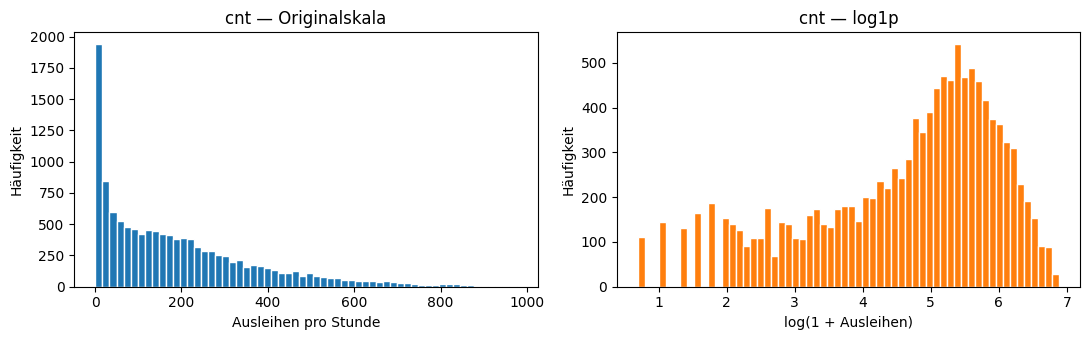

Schiefe (Original): 1.271
Schiefe (log1p):    -0.813


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(y_train, bins=60, edgecolor="white")
axes[0].set_title("cnt — Originalskala")
axes[0].set_xlabel("Ausleihen pro Stunde")
axes[1].hist(np.log1p(y_train), bins=60, edgecolor="white", color="C1")
axes[1].set_title("cnt — log1p")
axes[1].set_xlabel("log(1 + Ausleihen)")
for ax in axes:
    ax.set_ylabel("Häufigkeit")
plt.tight_layout()
plt.show()
print(f"Schiefe (Original): {y_train.skew():.3f}")
print(f"Schiefe (log1p):    {np.log1p(y_train).skew():.3f}")

## 4 · Hyperparameter

Beide Modelle verwenden über alle drei Loss-Optionen **identische** Parameter.
Die Werte sind auf den M4 Pro abgestimmt (Apple Silicon, 12 Performance-Kerne).

### XGBoost
- `n_estimators=800`, `learning_rate=0.03`: mehr Bäume mit kleinerer Schrittweite
  → bessere Generalisierung als 400 Bäume mit 0.05
- `max_depth=7`: etwas tiefer als zuvor (6), M4 Pro schafft das ohne Wartezeit
- `n_jobs=-1`: alle Performance-Kerne nutzen

### EBM
- `interactions=15`: 5 mehr als zuvor; EBM profitiert stark von Paarinteraktionen
- `max_bins=512`: feinere Binning-Grenzen, ~2× mehr Granularität
- `n_jobs=-1`: EBM parallelisiert die Feature-Runden über Kerne

In [4]:
xgb_params = dict(
    n_estimators=800,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    enable_categorical=True,
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0,
)

ebm_params = dict(
    interactions=15,
    max_bins=512,
    learning_rate=0.02,
    max_rounds=10000,
    early_stopping_rounds=100,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print("XGBoost-Parameter:")
for k, v in xgb_params.items():
    print(f"  {k:25s} = {v}")
print("\nEBM-Parameter:")
for k, v in ebm_params.items():
    print(f"  {k:25s} = {v}")

XGBoost-Parameter:
  n_estimators              = 800
  max_depth                 = 7
  learning_rate             = 0.03
  subsample                 = 0.8
  colsample_bytree          = 0.8
  min_child_weight          = 3
  reg_lambda                = 1.0
  enable_categorical        = True
  tree_method               = hist
  n_jobs                    = -1
  random_state              = 42
  verbosity                 = 0

EBM-Parameter:
  interactions              = 15
  max_bins                  = 512
  learning_rate             = 0.02
  max_rounds                = 10000
  early_stopping_rounds     = 100
  n_jobs                    = -1
  random_state              = 42


## 5 · Trainingsschleife

In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
all_results = {}

for LOSS in LOSS_OPTIONS.values():
    print(f"\n{'='*60}")
    print(f"  {LOSS.label}")
    print(f"{'='*60}")

    # XGBoost
    xgb = XGBRegressor(objective=LOSS.xgb_objective, **xgb_params)
    t0 = time.time()
    xgb.fit(X_train, y_train)
    xgb_train_time = time.time() - t0
    print(f"  XGBoost trainiert in {xgb_train_time:.2f} s")

    # EBM
    ebm = ExplainableBoostingRegressor(objective=LOSS.ebm_objective, **ebm_params)
    t0 = time.time()
    ebm.fit(X_train, y_train)
    ebm_train_time = time.time() - t0
    print(f"  EBM     trainiert in {ebm_train_time:.2f} s")

    # Vorhersagen + Metriken
    pred_xgb = xgb.predict(X_test)
    pred_ebm = ebm.predict(X_test)
    metrics_xgb = compute_metrics(y_test, pred_xgb)
    metrics_ebm = compute_metrics(y_test, pred_ebm)

    print(f"  XGBoost  RMSE={metrics_xgb['rmse']:.2f}  R²={metrics_xgb['r2']:.4f}  "
          f"neg.Preds={metrics_xgb['n_negative_predictions']}")
    print(f"  EBM      RMSE={metrics_ebm['rmse']:.2f}  R²={metrics_ebm['r2']:.4f}  "
          f"neg.Preds={metrics_ebm['n_negative_predictions']}")

    # Modelle speichern
    save_model(xgb, "xgb", LOSS.key)
    save_model(ebm, "ebm", LOSS.key)

    # Metriken-JSON speichern (wird von 02_Comparison.ipynb gelesen)
    result = {
        "loss_option": {
            "key":                LOSS.key,
            "label":              LOSS.label,
            "description":        LOSS.description,
            "ebm_objective":      LOSS.ebm_objective,
            "xgb_objective":      LOSS.xgb_objective,
            "contribution_space": LOSS.contribution_space,
        },
        "training_time_seconds": {
            "xgb": xgb_train_time,
            "ebm": ebm_train_time,
        },
        "metrics": {
            "xgb": metrics_xgb,
            "ebm": metrics_ebm,
        },
        "n_train": int(len(X_train)),
        "n_test":  int(len(X_test)),
        "hyperparameters": {
            "xgb": {**xgb_params, "objective": LOSS.xgb_objective},
            "ebm": {**ebm_params, "objective": LOSS.ebm_objective},
        },
    }
    out_path = RESULTS_DIR / f"model_metrics_{LOSS.key}.json"
    out_path.write_text(json.dumps(result, indent=2, default=str))
    all_results[LOSS.key] = result

print(f"\nFertig. Gespeichert: {list(LOSS_OPTIONS)}")


  Option 1: Squared Error
  XGBoost trainiert in 1.98 s
  EBM     trainiert in 13.77 s
  XGBoost  RMSE=39.13  R²=0.9515  neg.Preds=108
  EBM      RMSE=55.31  R²=0.9032  neg.Preds=358

  Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  XGBoost trainiert in 2.20 s
  EBM     trainiert in 12.79 s
  XGBoost  RMSE=39.01  R²=0.9518  neg.Preds=0
  EBM      RMSE=48.37  R²=0.9259  neg.Preds=0

  Option 3: Poisson-Deviance (Beitraege approximativ auf Ausleihe-Skala)
  XGBoost trainiert in 1.94 s
  EBM     trainiert in 13.15 s
  XGBoost  RMSE=39.01  R²=0.9518  neg.Preds=0
  EBM      RMSE=48.37  R²=0.9259  neg.Preds=0

Fertig. Gespeichert: ['squared_error', 'poisson_log', 'poisson_native']


## 6 · Ergebnistabelle

In [6]:
rows = []
for key, r in all_results.items():
    for model_name in ("xgb", "ebm"):
        m = r["metrics"][model_name]
        rows.append({
            "Option":             r["loss_option"]["key"],
            "Modell":             model_name.upper(),
            "RMSE":               round(m["rmse"], 2),
            "MAE":                round(m["mae"], 2),
            "R²":                 round(m["r2"], 4),
            "Poisson-Dev.":       round(m["poisson_deviance"], 4),
            "neg. Preds":         m["n_negative_predictions"],
            "Training (s)":       round(r["training_time_seconds"][model_name], 1),
        })

summary = pd.DataFrame(rows)
display(summary)

# Sanity-Check: Option 2 und 3 müssen auf Modell-Ebene identisch sein
if "poisson_log" in all_results and "poisson_native" in all_results:
    for mn in ("xgb", "ebm"):
        m2 = all_results["poisson_log"]["metrics"][mn]
        m3 = all_results["poisson_native"]["metrics"][mn]
        diff = max(abs(m2[k] - m3[k]) for k in ("rmse", "mae", "r2"))
        status = "✓ identisch" if diff < 1e-9 else f"⚠ Δ={diff:.2e}"
        print(f"Option 2 vs 3 — {mn.upper()}: {status}")

,Option,Modell,RMSE,MAE,R²,Poisson-Dev.,neg. Preds,Training (s)
0,squared_error,XGB,39.13,24.31,0.9515,12.0329,108,2.0
1,squared_error,EBM,55.31,36.19,0.9032,59.9873,358,13.8
2,poisson_log,XGB,39.01,23.68,0.9518,7.0615,0,2.2
3,poisson_log,EBM,48.37,27.00,0.9259,9.7242,0,12.8
4,poisson_native,XGB,39.01,23.68,0.9518,7.0615,0,1.9
5,poisson_native,EBM,48.37,27.00,0.9259,9.7242,0,13.1


Option 2 vs 3 — XGB: ✓ identisch
Option 2 vs 3 — EBM: ✓ identisch


## 7 · Diagnostik: Vorhersage vs. Wahrheit

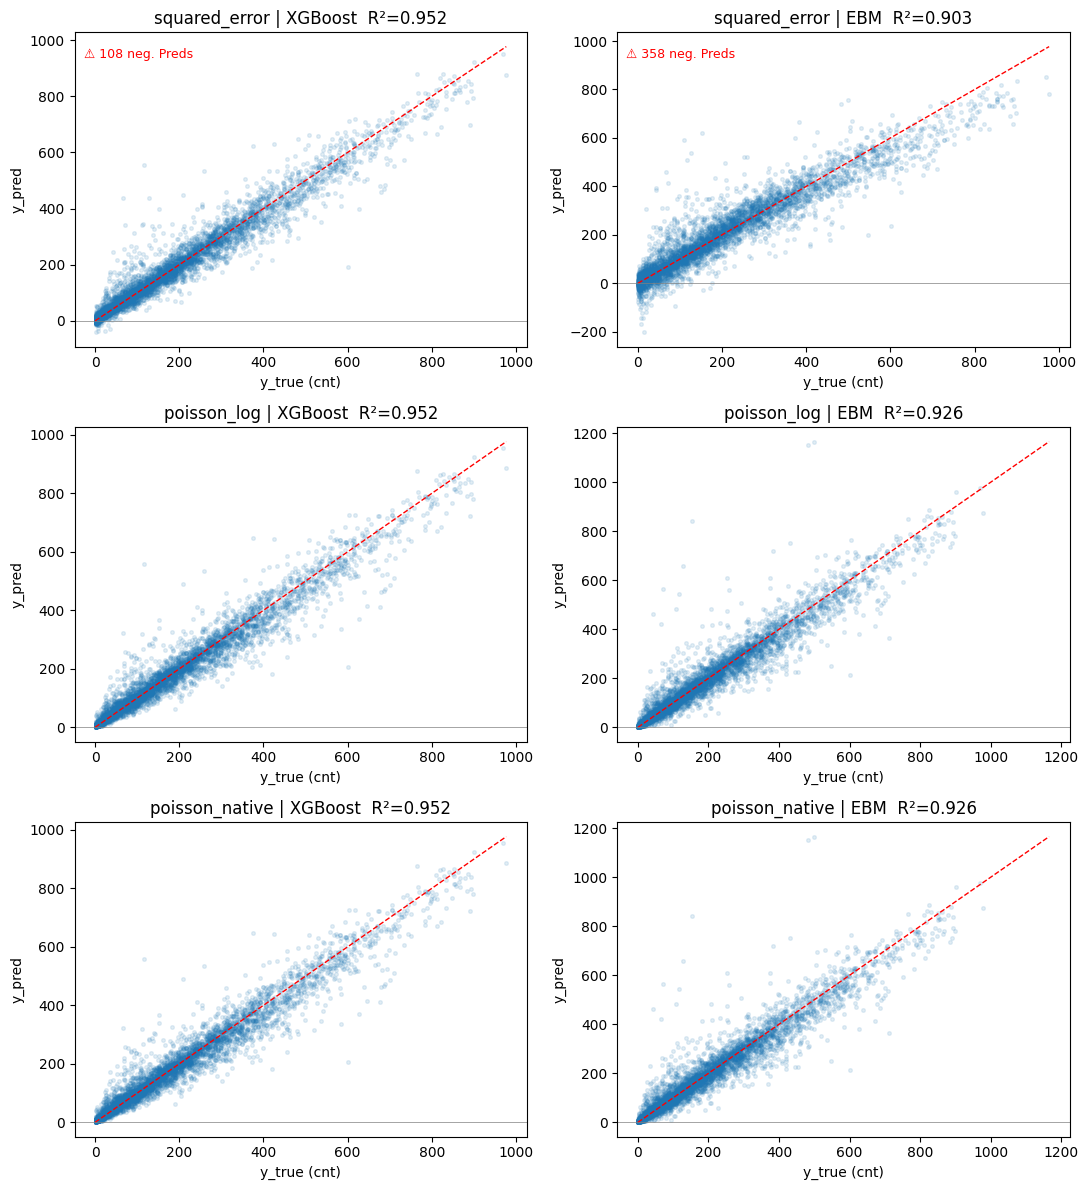

In [7]:
fig, axes = plt.subplots(len(all_results), 2, figsize=(11, 4 * len(all_results)))
if len(all_results) == 1:
    axes = [axes]

for row_idx, (key, r) in enumerate(all_results.items()):
    import joblib
    from utils import MODELS_DIR
    xgb_m = joblib.load(MODELS_DIR / f"xgb_{key}.pkl")
    ebm_m = joblib.load(MODELS_DIR / f"ebm_{key}.pkl")
    label = r["loss_option"]["key"]

    for col_idx, (model_obj, name) in enumerate([(xgb_m, "XGBoost"), (ebm_m, "EBM")]):
        ax = axes[row_idx][col_idx]
        pred = model_obj.predict(X_test)
        ax.scatter(y_test, pred, alpha=0.12, s=7)
        lim = max(float(y_test.max()), float(pred.max()))
        ax.plot([0, lim], [0, lim], "r--", lw=1)
        ax.axhline(0, color="gray", lw=0.5)
        ax.set_xlabel("y_true (cnt)")
        ax.set_ylabel("y_pred")
        m = compute_metrics(y_test, pred)
        ax.set_title(f"{label} | {name}  R²={m['r2']:.3f}")
        if m["n_negative_predictions"] > 0:
            ax.text(0.02, 0.95, f"⚠ {m['n_negative_predictions']} neg. Preds",
                    transform=ax.transAxes, color="red", fontsize=9, va="top")

plt.tight_layout()
plt.show()